## Задание

Численно решить задачу о сферических акустических волнах.

$$
\begin{cases}
\begin{align*}
 &U_{tt} = \frac{a^2}{r^2} \frac{\partial}{\partial r} \left(r^2 \frac{\partial U}{\partial r}\right) + f(r, t),  & 0 < t, \; 0 < r < R, &\\
 &\lim\limits_{r \rightarrow 0} r^2 \frac{\partial U}{\partial r} = 0,  & t > 0, &\\
 &U(R, t) + \frac{\partial U}{\partial r}(R, t) = (1 + R)^2 (1 + t) = \alpha(t),  & t > 0, &\\
 &U(r, 0) = 1 + r^2 = \phi(r),  & 0 < r < R, &\\
 &U_t(r, 0) = 1 + r^2 = \psi(r),  & 0 < r < R, &
\end{align*}
\end{cases}
$$

boundleft 0, f = 0, U(r, 0) = R - r, U_t = 0

где источник задан как:

$$
f(r, t) = -6a^2(1 + t)
$$

и $a, R \in \mathbb{R}$ — константы.

## Точное решение

Точное решение задачи имеет вид:

$$
U_0(r, t) = (1 + r^2)(1 + t)
$$

In [256]:
from typing import Callable, Generator

In [257]:
import numpy as np

In [258]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

In [259]:
R = 1.0
a = 2.0
T = 5.0
h = 0.02
tau = 0.5 * h / a

In [260]:
def f(r: np.ndarray, t: float) -> np.ndarray:
    return -6 * a**2 * (1 + t)

def u_exact(r: np.ndarray, t: float) -> np.ndarray:
    return (1 + r**2) * (1 + t)

def alpha(t: float) -> float:
    return (1 + R)**2 * (1 + t)

def phi(r: np.ndarray) -> np.ndarray:
    return 1 + r**2

def psi(r: np.ndarray) -> np.ndarray:
    return 1 + r**2

# Numerical solution

In [261]:
def compute_laplacian(u: np.ndarray, r: np.ndarray) -> np.ndarray:
    lap = np.zeros(len(u))
    i = slice(1, -1)
    u_rr = (u[2:] - 2*u[1:-1] + u[:-2]) / h**2
    u_r = (u[2:] - u[:-2]) / (2*h)
    mask = r[1:-1] > 0
    lap[1:-1][mask] = u_rr[mask] + (2/r[1:-1][mask]) * u_r[mask]
    if r[1] == 0:
        lap[1] = 6 * (u[2] - u[1]) / h**2
    return lap

In [262]:
def boundary_r0(u_prev: np.ndarray, u_curr: np.ndarray, t: float, f: Callable) -> float:
    laplacian_term = 6 * a**2 / h**2 * (u_curr[1] - u_curr[0])
    source_term = f(h / 4, t)
    return 2 * u_curr[0] - u_prev[0] + tau**2 * (laplacian_term + source_term)

def boundary_rR(u_curr: np.ndarray, u_prev: np.ndarray, t: float, f: Callable) -> float:
    u_ghost = u_curr[-2] + 2 * h * (alpha(t) - u_curr[-1])
    u_rr = (u_ghost - 2 * u_curr[-1] + u_curr[-2]) / h**2
    u_r = (u_ghost - u_curr[-2]) / (2 * h * R)
    laplacian = u_rr + (2 / R) * u_r
    return 2 * u_curr[-1] - u_prev[-1] + tau**2 * (a**2 * laplacian + f(R, t))

In [263]:
def initialize_first_step(u_prev: np.ndarray, r: np.ndarray) -> np.ndarray:
    u_curr = np.zeros(len(r))
    lap = compute_laplacian(u_prev, r)
    u_ghost = u_prev[-2] + 2 * h * (alpha(0) - u_prev[-1])
    u_rr_R = (u_ghost - 2 * u_prev[-1] + u_prev[-2]) / h**2
    u_r_R = (u_ghost - u_prev[-2]) / (2 * h * R)
    lap[-1] = u_rr_R + (2 / R) * u_r_R
    lap[0] = 6 * a**2 / h**2 * (u_prev[1] - u_prev[0]) + f(h / 4, 0) / a**2
    u_curr[1:] = u_prev[1:] + tau * psi(r[1:]) + 0.5 * tau**2 * (a**2 * lap[1:] + f(r[1:], 0))
    u_curr[0] = u_prev[0] + tau * psi(r[0]) + 0.5 * tau**2 * (a**2 * lap[0] + f(h / 4, 0))
    return u_curr

In [264]:
def time_step(u_prev: np.ndarray, u_curr: np.ndarray, t: float, r: np.ndarray) -> np.ndarray:
    u_next = np.zeros(len(r))
    lap = compute_laplacian(u_curr, r)
    u_next[1:-1] = 2 * u_curr[1:-1] - u_prev[1:-1] + tau**2 * (a**2 * lap[1:-1] + f(r[1:-1], t))
    u_next[0] = boundary_r0(u_prev, u_curr, t, f)
    u_next[-1] = boundary_rR(u_curr, u_prev, t, f)
    return u_next

In [265]:
def solve():
    global h

    n = int(R / h) + 1
    r = np.linspace(0, R, n)
    h = r[1] - r[0]

    u_prev = phi(r)
    u_curr = initialize_first_step(u_prev, r)
    t = tau
    max_error = 0.0

    err = np.max(np.abs(u_exact(r, 0) - u_prev))
    max_error = max(max_error, err)
    yield {'u': u_prev, 'r': r, 't': 0.0, 'max_error': max_error}

    err = np.max(np.abs(u_exact(r, t) - u_curr))
    max_error = max(max_error, err)
    yield {'u': u_curr, 'r': r, 't': t, 'max_error': max_error}

    while t < T - tau / 2:
        u_next = time_step(u_prev, u_curr, t, r)
        t += tau
        u_prev, u_curr = u_curr, u_next
        err = np.max(np.abs(u_exact(r, t) - u_curr))
        max_error = max(max_error, err)
        yield {'u': u_curr, 'r': r, 't': t, 'max_error': max_error}

In [266]:
def test_convergence(h_values: np.ndarray = None) -> float:
    if h_values is None:
        h_values = np.logspace(-2.5, -2, 7, base=10)

    errors = []
    print("Testing convergence order...")
    print("-" * 50)

    for h_val in h_values:
        global h, tau
        h = h_val
        tau = 0.5 * h / a

        result = None
        for sol in solve():
            result = sol

        errors.append(result['max_error'])
        print(f"h = {h_val:.6f}, Max Error = {result['max_error']:.6e}")

    errors = np.array(errors)
    h_log = np.log(h_values)
    err_log = np.log(errors)
    order = np.polyfit(h_log, err_log, 1)[0]

    print("-" * 50)
    print(f"Convergence Order: {order:.4f}")

    plt.figure(figsize=(8, 6))
    plt.loglog(h_values, errors, 'bo-', linewidth=2, markersize=8, label='Max Error')
    plt.loglog(h_values, h_values**2 * errors[0] / h_values[0]**2, 'r--', linewidth=2, label='O(h²)')
    plt.xlabel('Spatial Step h', fontsize=12)
    plt.ylabel('Max Error', fontsize=12)
    plt.title('Convergence Order Analysis', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return order

In [267]:
def animate_solution(filename: str = 'spherical_wave.mp4', frame_skip: int = 2):
    from matplotlib.gridspec import GridSpec

    solver = solve()
    print("Collecting data for animation...")
    results = []
    for sol in solver:
        results.append(sol)

    all_u = np.concatenate([r['u'] for r in results])
    all_exact = np.concatenate([u_exact(r['r'], r['t']) for r in results])
    global_min = min(all_u.min(), all_exact.min())
    global_max = max(all_u.max(), all_exact.max())
    y_padding = (global_max - global_min) * 0.1

    all_errors = []
    for r in results:
        err = np.abs(r['u'] - u_exact(r['r'], r['t']))
        all_errors.append(err.max())
    global_err_max = max(all_errors) * 1.2

    fig = plt.figure(figsize=(16, 8))
    gs = GridSpec(2, 3, figure=fig, width_ratios=[2, 2, 1], height_ratios=[1, 1])

    ax1 = fig.add_subplot(gs[:, :2])
    line_num, = ax1.plot([], [], 'r-', lw=2, label='Numerical')
    line_exact, = ax1.plot([], [], 'b--', lw=2, label='Exact', alpha=0.8)
    ax1.set_xlabel('r', fontsize=14)
    ax1.set_ylabel('U(r,t)', fontsize=14)
    ax1.set_title('Spherical Acoustic Wave', fontsize=16, fontweight='bold')
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.legend(loc='upper right', fontsize=12)
    ax1.set_xlim(0, R)
    ax1.set_ylim(global_min - y_padding, global_max + y_padding)

    ax2 = fig.add_subplot(gs[0, 2])
    line_err, = ax2.plot([], [], 'g-', lw=2)
    ax2.set_xlabel('r', fontsize=12)
    ax2.set_ylabel('Error', fontsize=12)
    ax2.set_title('Absolute Error', fontsize=14)
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.set_xlim(0, R)
    ax2.set_ylim(0, global_err_max)

    ax3 = fig.add_subplot(gs[1, 2])
    times = [r['t'] for r in results]
    errors_history = [r['max_error'] for r in results]
    line_history, = ax3.plot([], [], 'mo-', markersize=3, linewidth=1.5)
    ax3.set_xlabel('Time (s)', fontsize=12)
    ax3.set_ylabel('Max Error', fontsize=12)
    ax3.set_title('Error Evolution', fontsize=14)
    ax3.grid(True, alpha=0.3, linestyle='--')
    ax3.set_xlim(0, T)
    ax3.set_ylim(0, max(errors_history) * 1.1)

    time_text = ax1.text(0.02, 0.98, '', transform=ax1.transAxes,
                         fontsize=14, fontweight='bold',
                         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    error_text = ax2.text(0.05, 0.95, '', transform=ax2.transAxes,
                          fontsize=12, fontweight='bold',
                          bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

    plt.tight_layout()

    def update(frame):
        result = results[frame]
        r = result['r']
        u = result['u']
        t = result['t']
        u_ex = u_exact(r, t)
        err = np.abs(u - u_ex)

        line_num.set_data(r, u)
        line_exact.set_data(r, u_ex)
        line_err.set_data(r, err)

        mask = np.array(times) <= t
        line_history.set_data(np.array(times)[mask], np.array(errors_history)[mask])

        time_text.set_text(f't = {t:.3f} s')
        error_text.set_text(f'Max: {result["max_error"]:.2e}')

        if hasattr(update, 'time_marker'):
            update.time_marker.remove()
        update.time_marker = ax3.axvline(x=t, color='red', linestyle='--', alpha=0.5, linewidth=1)

        return line_num, line_exact, line_err, line_history, update.time_marker, time_text, error_text

    update.time_marker = ax3.axvline(x=0, color='red', linestyle='--', alpha=0.5, linewidth=1)

    n_frames = len(results)
    frame_step = max(1, frame_skip)
    frames_to_show = range(0, n_frames, frame_step)

    interval = (tau * frame_step * 1000)

    anim = animation.FuncAnimation(fig, update, frames=frames_to_show,
                         interval=interval, blit=True, repeat=True)

    if filename:
        print(f"Saving animation to {filename}...")
        anim.save(filename, writer='ffmpeg', fps=30, dpi=150)
        print("Animation saved!")

    plt.show()
    return anim

In [268]:
def plot_3d_spherical():
    from mpl_toolkits.mplot3d import Axes3D

    result = None
    for sol in solve():
        result = sol

    r = result['r']
    u = result['u']

    theta = np.linspace(0, 2*np.pi, 60)
    R_grid, Theta = np.meshgrid(r, theta)
    X = R_grid * np.cos(Theta)
    Y = R_grid * np.sin(Theta)
    U_grid = np.tile(u, (len(theta), 1))

    fig = plt.figure(figsize=(14, 6))

    ax1 = fig.add_subplot(121, projection='3d')
    surf = ax1.plot_surface(X, Y, U_grid, cmap='viridis', alpha=0.9)
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.set_zlabel('U')
    ax1.set_title(f'Numerical Solution at t = {result["t"]:.3f} s')
    fig.colorbar(surf, ax=ax1, shrink=0.5)

    ax2 = fig.add_subplot(122, projection='3d')
    U_exact_grid = np.tile(u_exact(r, result['t']), (len(theta), 1))
    surf2 = ax2.plot_surface(X, Y, U_exact_grid, cmap='plasma', alpha=0.9)
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.set_zlabel('U')
    ax2.set_title(f'Exact Solution at t = {result["t"]:.3f} s')
    fig.colorbar(surf2, ax=ax2, shrink=0.5)

    plt.tight_layout()
    plt.show()

def animate_3d_spherical(filename='spherical_3d.mp4', frame_skip=5):
    from mpl_toolkits.mplot3d import Axes3D
    from matplotlib.animation import FuncAnimation

    solver = solve()
    print("Collecting data for 3D animation...")
    results = []
    for sol in solver:
        results.append(sol)

    theta = np.linspace(0, 2*np.pi, 40)

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    def update(frame):
        ax.clear()
        result = results[frame]
        r = result['r']
        u = result['u']
        t = result['t']

        R_grid, Theta = np.meshgrid(r, theta)
        X = R_grid * np.cos(Theta)
        Y = R_grid * np.sin(Theta)
        U_grid = np.tile(u, (len(theta), 1))

        surf = ax.plot_surface(X, Y, U_grid, cmap='coolwarm', alpha=0.9)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_zlabel('U')
        ax.set_title(f'Spherical Wave at t = {t:.3f} s')
        ax.set_zlim(0, 12)

        return surf,

    n_frames = len(results)
    frame_step = max(1, frame_skip)
    frames_to_show = range(0, n_frames, frame_step)

    anim = FuncAnimation(fig, update, frames=frames_to_show, interval=100, blit=False)

    if filename:
        print(f"Saving 3D animation to {filename}...")
        anim.save(filename, writer='ffmpeg', fps=20, dpi=100)
        print("Animation saved!")

    plt.show()
    return anim

SPHERICAL ACOUSTIC WAVE EQUATION SOLVER
Domain: 0 ≤ r ≤ 1.0
Wave speed: a = 2.0
Final time: T = 5.0
Spatial step: h = 0.02
Time step: τ = 0.005000 (CFL condition)

Running solver...

Final time: t = 5.0000
Max error: 6.196771e-04
Testing convergence order...
--------------------------------------------------
h = 0.003162, Max Error = 1.549642e-05
h = 0.003831, Max Error = 2.273960e-05
h = 0.004642, Max Error = 3.340401e-05
h = 0.005623, Max Error = 4.908228e-05
h = 0.006813, Max Error = 7.206254e-05
h = 0.008254, Max Error = 1.055988e-04
h = 0.010000, Max Error = 1.549193e-04
--------------------------------------------------
Convergence Order: 2.0003


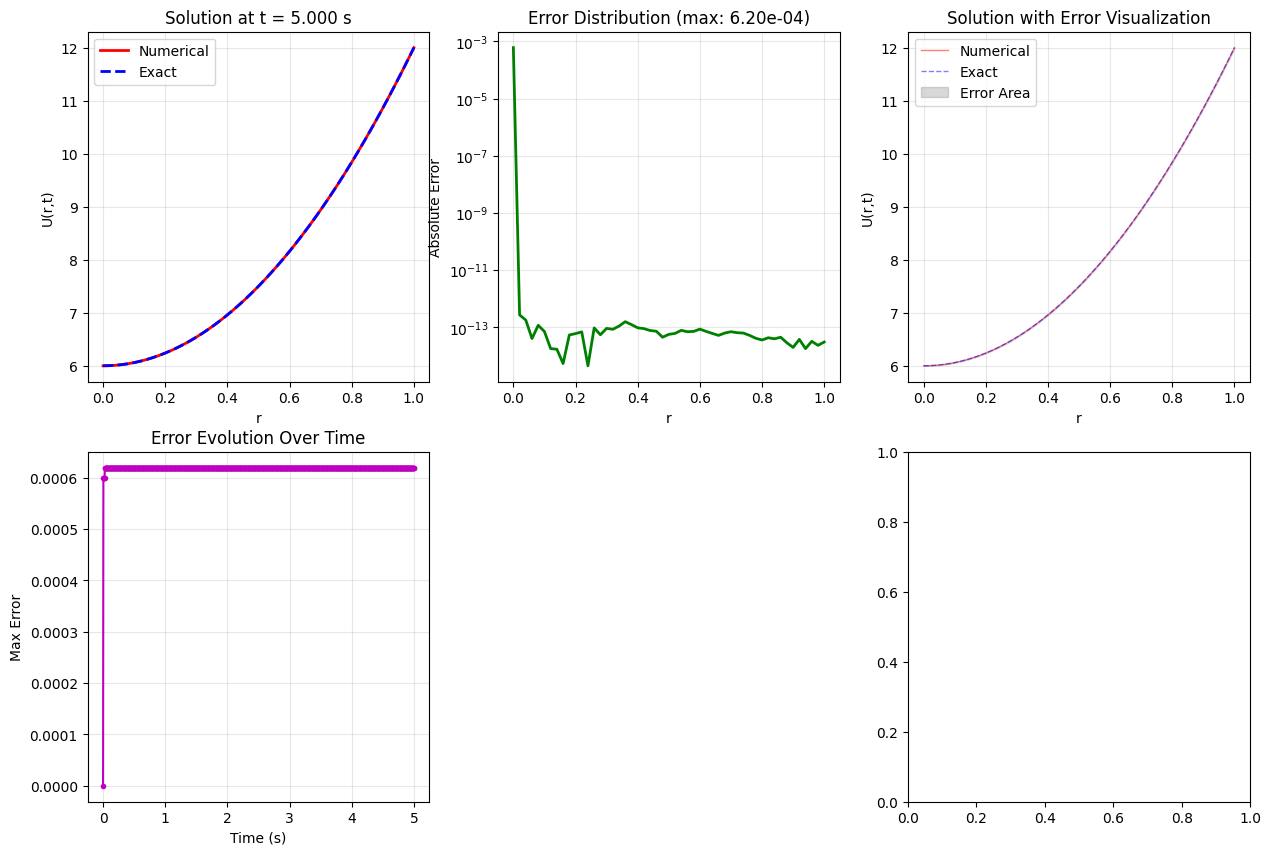

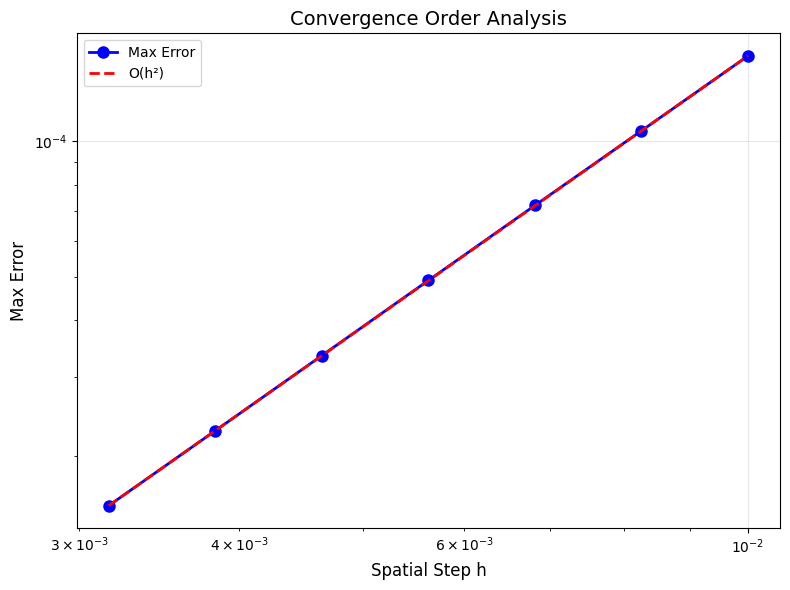

<Figure size 640x480 with 0 Axes>

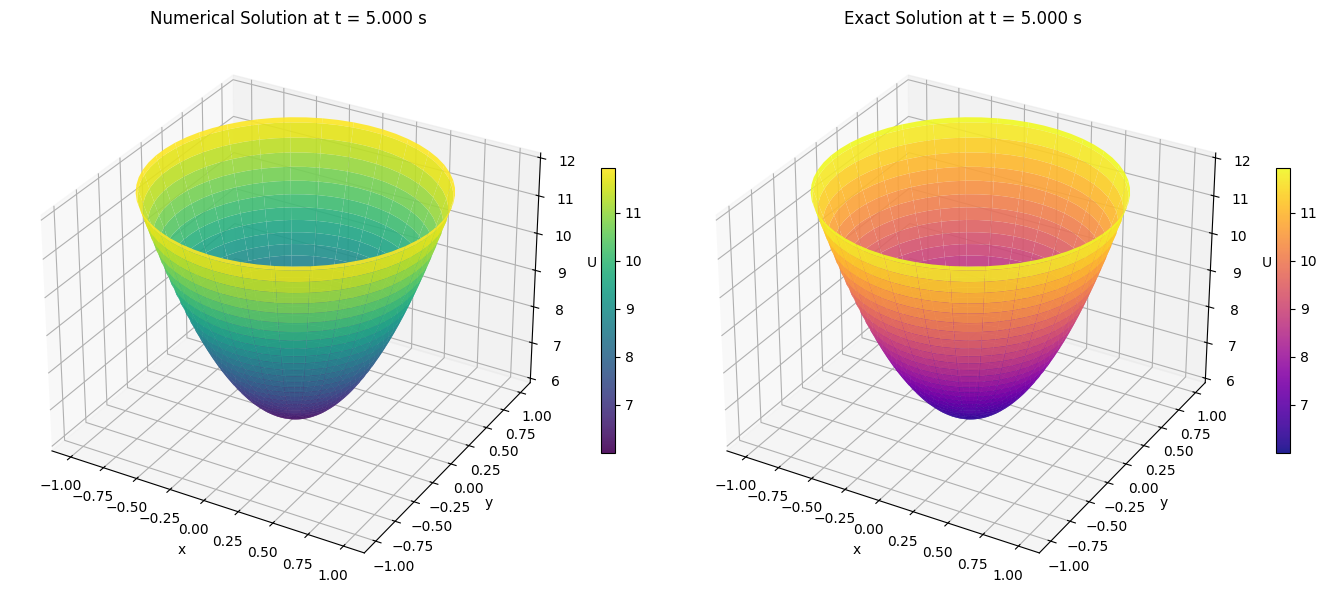


Creating 2D animation...
Saving animation to spherical_wave.mp4...


CalledProcessError: Command '['ffmpeg', '-f', 'rawvideo', '-vcodec', 'rawvideo', '-s', '2400x1200', '-pix_fmt', 'rgba', '-framerate', '30', '-loglevel', 'error', '-i', 'pipe:', '-vcodec', 'h264', '-pix_fmt', 'yuv420p', '-y', 'spherical_wave.mp4']' returned non-zero exit status 255.

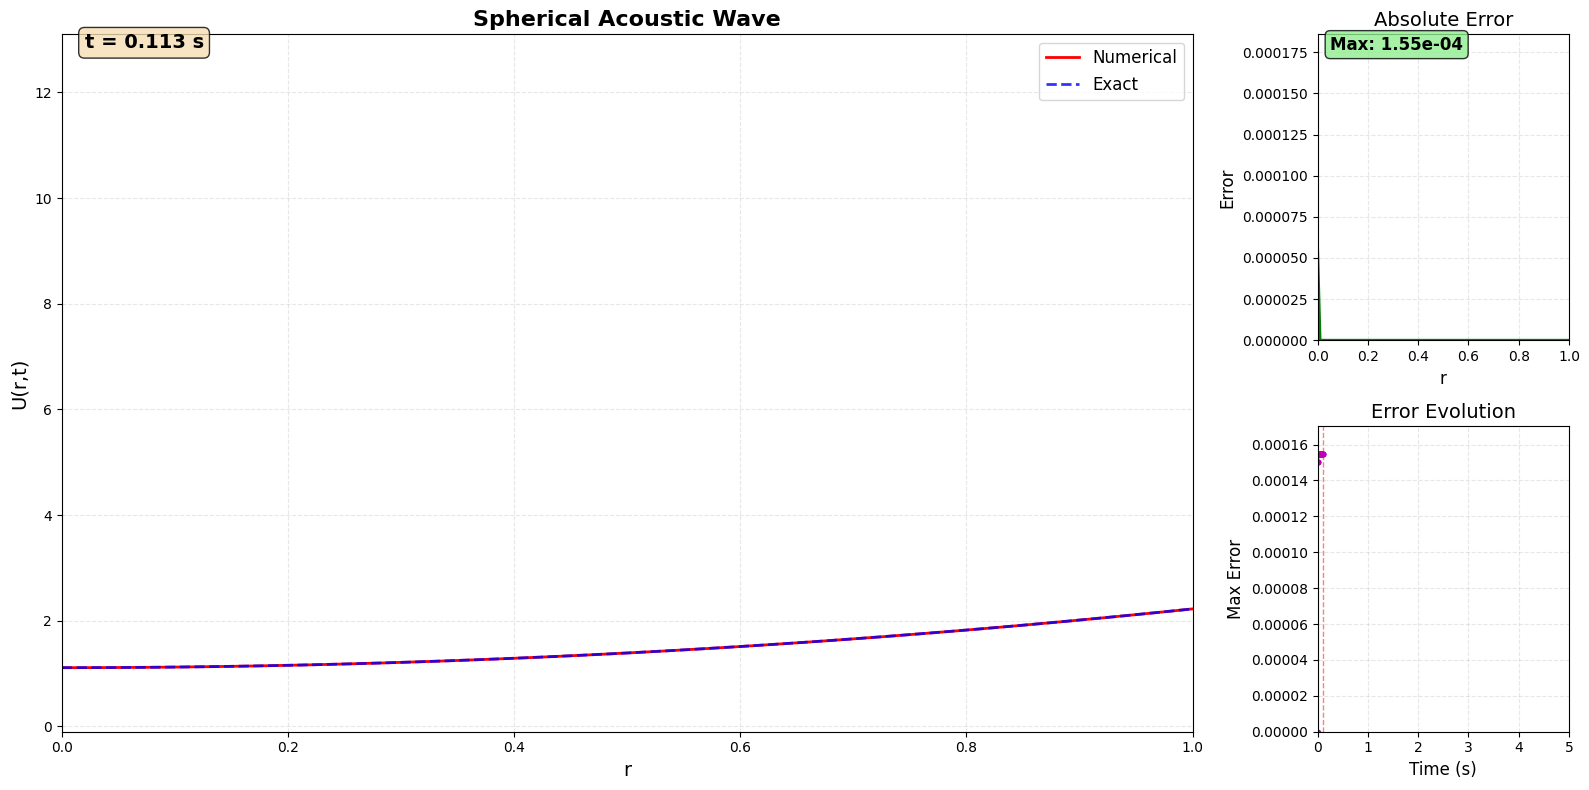

In [269]:

if __name__ == "__main__":
    print("=" * 60)
    print("SPHERICAL ACOUSTIC WAVE EQUATION SOLVER")
    print("=" * 60)
    print(f"Domain: 0 ≤ r ≤ {R}")
    print(f"Wave speed: a = {a}")
    print(f"Final time: T = {T}")
    print(f"Spatial step: h = {h}")
    print(f"Time step: τ = {tau:.6f} (CFL condition)")
    print("=" * 60)

    print("\nRunning solver...")
    result = None
    for sol in solve():
        result = sol

    print(f"\nFinal time: t = {result['t']:.4f}")
    print(f"Max error: {result['max_error']:.6e}")

    plt.figure(figsize=(15, 10))

    plt.subplot(2, 3, 1)
    plt.plot(result['r'], result['u'], 'r-', lw=2, label='Numerical')
    plt.plot(result['r'], u_exact(result['r'], result['t']), 'b--', lw=2, label='Exact')
    plt.xlabel('r')
    plt.ylabel('U(r,t)')
    plt.title(f'Solution at t = {result["t"]:.3f} s')
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.subplot(2, 3, 2)
    error = np.abs(result['u'] - u_exact(result['r'], result['t']))
    plt.semilogy(result['r'], error, 'g-', lw=2)
    plt.xlabel('r')
    plt.ylabel('Absolute Error')
    plt.title(f'Error Distribution (max: {result["max_error"]:.2e})')
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 3, 3)
    plt.plot(result['r'], result['u'], 'r-', lw=1, alpha=0.5, label='Numerical')
    plt.plot(result['r'], u_exact(result['r'], result['t']), 'b--', lw=1, alpha=0.5, label='Exact')
    plt.fill_between(result['r'], result['u'], u_exact(result['r'], result['t']),
                     alpha=0.3, color='gray', label='Error Area')
    plt.xlabel('r')
    plt.ylabel('U(r,t)')
    plt.title('Solution with Error Visualization')
    plt.grid(True, alpha=0.3)
    plt.legend()

    times = []
    errors_over_time = []
    for sol in solve():
        times.append(sol['t'])
        errors_over_time.append(sol['max_error'])

    plt.subplot(2, 3, 4)
    plt.plot(times, errors_over_time, 'mo-', markersize=3, linewidth=1.5)
    plt.xlabel('Time (s)')
    plt.ylabel('Max Error')
    plt.title('Error Evolution Over Time')
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 3, 6)
    test_convergence()

    plt.tight_layout()
    plt.show()

    plot_3d_spherical()

    print("\nCreating 2D animation...")
    animate_solution(filename='spherical_wave.mp4', frame_skip=5)

    print("\nCreating 3D animation...")
    animate_3d_spherical(filename='spherical_3d.mp4', frame_skip=5)